In [1]:
from ProtMamba_ssm.utils import *
from ProtMamba_ssm.dataloaders import *
from ProtMamba_ssm.modules import *
from aux_msa_functions import *

import numpy as np
import torch
import os
from typing import List, Tuple, Optional, Dict, NamedTuple, Union, Callable
from Bio import SeqIO, Phylo


In [2]:
GH19_MSA = read_msa("GH19_Curated_MSA.fasta")
GH19_ancestors = read_msa('GH19_Ancestors_Library.fasta')
Antifungal_chitinases = read_msa('Antifungal_Chitinases.fasta')
GH19_seqs = read_msa('GH19_plant.txt')
GH19_labelled_seqs = read_msa('GH19_labeled.txt')

### Contexts from catalytic domain

In [4]:
loop_contexts = pd.Series([x[0].split('_')[1] for x in GH19_labelled_seqs]).unique()

contexts_dict = {}

for context in loop_contexts:
    contexts_dict[context] = []

for i in range(len(GH19_MSA)):

    context = GH19_MSA[i][0].split('_')[1]
    contexts_dict[context].append(GH19_MSA[i])

KeyError: '001000'

In [189]:
for context in contexts_dict:

    Seq_tuples_to_fasta(contexts_dict[context],f"./contexts/loops_{context}.fasta")

### Contexts from Binding + Catalytic domain

In [153]:
loop_contexts = pd.Series([(x[0].split('_')[0],x[0].split('_')[2]) if len(x[0].split('_')) >= 3 else None for x in GH19_labelled_seqs]).unique()
loop_contexts = loop_contexts[~pd.isnull(loop_contexts)]

contexts_dict = {}

for context in loop_contexts:
    contexts_dict[context] = []

for i in range(len(GH19_labelled_seqs)):

    try:
        context = (GH19_labelled_seqs[i][0].split('_')[0], GH19_labelled_seqs[i][0].split('_')[2])
    except:
        continue
    
    contexts_dict[context].append(GH19_labelled_seqs[i])

for context in contexts_dict:
    Seq_tuples_to_fasta(contexts_dict[context],f"./contexts/loops_{context[0]}_{context[1]}.fasta")

contexts_dict["all_both_domains"] = [x for x in GH19_labelled_seqs if x[0].split('_')[0] == "Full"]
Seq_tuples_to_fasta(contexts_dict[context],f"./contexts/loops_all_both_domains.fasta")



In [ ]:
### Test all ancestors and their variants in the Ancestors library and the antifungal chitinases (measure average probabilities in loop areas)
### Define interesting contexts for testing - all sequences, loopless only, 1 loops, 2 loops etc.



### Correlations of Mean Loop Likelihoods and Antifungal Resistance

In [3]:
Loop_lengths = [7,13, 8, 5, 12, 7]
Loop_start_points = [14, 64, 91, 156, 170, 231]
Loop_ID_mappings = {"LI":1, "LII":2, "LIII":3,"LIV":4,"LV":5,"LC":6}

In [4]:
torch.cuda.empty_cache()

device = "cuda" if torch.cuda.is_available() else "cpu"

model = load_model("./ProtMamba-Long-foundation",
            model_class=MambaLMHeadModelwithPosids,
            device="cuda",
            dtype=torch.bfloat16,
            checkpoint_mixer=False # Must be False when using model for Inference
            )

model = model.to(device)
    
def fim(target_seq, context_seqs, selected_pos_list, original_length_list, gen_length_list, loop_numbers):
    

    context_seqs = [x for x in context_seqs  if target_seq[0].replace("-","") != x[1].replace("-","")]

    context = tokenizer([seq[1] for seq in context_seqs], concatenate=True)
    target = tokenizer(target_seq, concatenate=True).to(device)
    
    original_seqs_list = []
    original_seq_tokens_list = []

    mask_dictionary = {}
    autoreg_dictionary = {}
    n_masks = len(selected_pos_list)
    
    mask_id = 1

    for i in range(len(selected_pos_list)):

        if original_length_list[i] == 0:
            continue

        original_seq_tokens = target[0][1:][selected_pos_list[i]:selected_pos_list[i] + original_length_list[i]]
        original_seqs_list.append(decode_sequence(original_seq_tokens.tolist()))
        original_seq_tokens_list.append(original_seq_tokens) 

        if loop_numbers[i] == 6:
            autoreg_dictionary["<cls>"] = selected_pos_list[i]
            continue

        mask_dictionary[f"<mask-{mask_id}>"] = ((selected_pos_list[i] + 1,selected_pos_list[i] + original_length_list[i] + 1),gen_length_list[i])

        mask_id += 1   
    
    if len(mask_dictionary) == 0 and len(autoreg_dictionary) == 0:
        return None
        
    softmax = nn.Softmax(dim=-1)

    average_orig_probs = []
    average_pred_probs = []
    median_orig_probs = []
    median_pred_probs = []
    pred_seqs = []  

    if len(mask_dictionary) != 0:       
        input_seq, targ_pos, is_fim_dict = prepare_target(target, use_fim=mask_dictionary)

        input_seq = input_seq.to(device)
        targ_pos = targ_pos.to(device)

        context_tokens, context_pos_ids = prepare_tokens(context,
                            target_tokens=input_seq,
                            target_pos_ids=targ_pos,
                            DatasetClass=Uniclust30_Dataset,
                            num_sequences=len(context_seqs),
                            fim_strategy="no-scramble",
                            mask_fraction=1,
                            max_patches=1,
                            add_position_ids="1d")  
        

        output = generate_sequence(model,
                    context_tokens,
                    position_ids=context_pos_ids,
                    is_fim=is_fim_dict,
                    max_length= context_tokens.shape[1] + 100,
                    temperature=1.,
                    top_k=10,
                    top_p=0.0,
                    mask_dictionary=mask_dictionary,
                    return_dict_in_generate=True,
                    output_scores=True,
                    eos_token_id=AA_TO_ID["<cls>"],
                    device="cuda")
        
        # print(decode_sequence(input_seq[0].tolist()))
        # print(targ_pos[0].tolist())

        # print(len(output["generated_tokens"][0]))
        # print(output["scores"][0].shape)
        print(output["generated"][0])
        
        cur_pos = 0
        generated_tokens = output["generated_tokens"][0]
        logits = torch.tensor(output["scores"][0])
        
        probabilities = softmax(logits).numpy()

        list_ind = 0
        
        for i in range(n_masks):

            if original_length_list[i] == 0:
                pred_seqs.append("")
                average_orig_probs.append(None)
                average_pred_probs.append(None)
                median_orig_probs.append(None)
                median_pred_probs.append(None)
                continue

            if loop_numbers[i] == 6:
                continue

            gen_length = gen_length_list[i]
            orig_length = original_length_list[i]

            gen_seq_tokens = generated_tokens[cur_pos + 1: cur_pos + gen_length + 1]
            
            orig_probs = []
            pred_probs = []

            
            for j,pos in enumerate(range(cur_pos + 1, cur_pos + gen_length + 1)):
                
                if len(pred_probs) <  gen_length:

                    pred_probs.append(probabilities[pos,generated_tokens[pos]])

                if len(orig_probs) < gen_length:
                    
                    orig_probs.append(probabilities[pos,original_seq_tokens_list[list_ind][j]])
            
            list_ind += 1


            average_orig_probs.append(np.mean(orig_probs))
            average_pred_probs.append(np.mean(pred_probs))
            median_orig_probs.append(np.median(orig_probs))
            median_pred_probs.append(np.median(pred_probs))
            pred_seqs.append(decode_sequence(gen_seq_tokens))

            cur_pos += gen_length + 1

    if len(autoreg_dictionary) != 0:

        input_seq, targ_pos = prepare_target(target, use_fim=autoreg_dictionary)

        while True:

            output = generate_sequence(model,
                                context,
                                position_ids=torch.tensor(list(range(context.shape[1])))[None,:],
                                is_fim=autoreg_dictionary,
                                max_length=context.shape[1] + original_length_list[-1],
                                temperature=1.,
                                top_k=10,
                                top_p=0.0,
                                return_dict_in_generate=True,
                                output_scores=True,
                                eos_token_id=torch.tensor([AA_TO_ID["<cls>"],AA_TO_ID["<mask-1>"], AA_TO_ID["<mask-2>"], AA_TO_ID["<mask-3>"],
                                                            AA_TO_ID["<mask-4>"], AA_TO_ID["<mask-5>"]]).to("cuda"),
                                device="cuda")
            
            output_seq = output["generated"][0]
            
            if "<" not in output_seq:
                break
            
        logits = torch.tensor(output["scores"][0])
        generated_tokens = output["generated_tokens"][0]
        probabilities = softmax(logits).numpy()
    
        orig_probs = []
        pred_probs = []

        # print(original_seqs_list[-1])

        for pos in range(len(output_seq)):
            
            pred_probs.append(probabilities[pos,generated_tokens[pos]])                
            orig_probs.append(probabilities[pos,original_seq_tokens_list[-1][pos]])
        
        average_orig_probs.append(np.mean(orig_probs))
        average_pred_probs.append(np.mean(pred_probs))
        median_orig_probs.append(np.median(orig_probs))
        median_pred_probs.append(np.median(pred_probs))
        pred_seqs.append(output_seq)

        # cur_pos += gen_length + 1

    output["average_orig_prob"] = average_orig_probs
    output["average_pred_prob"] = average_pred_probs
    output["median_orig_prob"] = median_orig_probs
    output["median_pred_prob"] = median_pred_probs
    output["pred_seqs"] = pred_seqs

    average_orig_probs = np.array(average_orig_probs)
    output["overall_average_orig_prob"] = np.mean(average_orig_probs[average_orig_probs != np.array(None)])

    average_pred_probs = np.array(average_pred_probs)
    output["overall_average_pred_prob"] = np.mean(average_pred_probs[average_pred_probs != np.array(None)])

    return output
    

Using a model that was pretrained with gradient checkpointing but now do not want to use it. Changed the keys of the state_dict to match the model's keys.


In [5]:
context_loops = "111111"

### Testing Ancestor Variants

In [6]:
GH19_ancestor_seqs = [list(anc[1]) for anc in GH19_ancestors[1:-1]]
GH19_ancestor_seqs = np.array(GH19_ancestor_seqs)
GH19_ancestor_seqs = GH19_ancestor_seqs[:,5:]
GH19_ancestor_seqs[:94,13] = GH19_ancestor_seqs[:94,20]
GH19_ancestor_seqs[:94, 20] = "-"
GH19_ancestor_seqs = GH19_ancestor_seqs[:,:-14]
GH19_ancestor_seqs = np.concatenate((GH19_ancestor_seqs[:,:202], GH19_ancestor_seqs[:,207:]), axis=1)
GH19_ancestor_seqs = np.concatenate((GH19_ancestor_seqs[:,:93], GH19_ancestor_seqs[:,94:]), axis=1)
GH19_ancestor_seqs = GH19_ancestor_seqs.tolist()
GH19_ancestor_seqs = [''.join(x) for x in GH19_ancestor_seqs]

GH19_ancestor_names = [seq[0] for seq in GH19_ancestors[1:-1]]
GH19_ancestors_clean = [(a,b) for a,b in zip(GH19_ancestor_names, GH19_ancestor_seqs)]

In [14]:
modified_loop_only = False

loop_to_ind_map = {1:0,2:1,3:2,4:3,5:4,6:5}

loops_to_include = [1,2,3,4,5,6]
loops_to_include_ind = [loop_to_ind_map[x] for x in loops_to_include]

inverse_loop_map = {0:1,1:2,2:3,3:4,4:5,5:6}

context_path = f"./contexts/loops_{context_loops}.fasta"

context_seqs_MSA = read_msa(context_path)

output_table = []

for ancestor in GH19_ancestors_clean:
    
    name_split = ancestor[0].split('_')

    if len(name_split) == 3:

        anc_id = name_split[0]
        mod_loop_name = name_split[1]
        mod_loop_number = Loop_ID_mappings[mod_loop_name]

        # if context_loops != "all":
        #     context_loops_bool = [bool(int(x)) for x in list(context_loops)]
        #     loops_to_include = np.array(range(1,7))[context_loops_bool].tolist()
        #     loops_to_include_ind = [loop_to_ind_map[x] for x in loops_to_include]

        
        # if mod_loop_number not in loops_to_include:
        #     loops_to_include += [mod_loop_number]
        #     loops_to_include = sorted(loops_to_include)
        #     loops_to_include_ind = [loop_to_ind_map[x] for x in loops_to_include]

        mod_loop_ind = loop_to_ind_map[mod_loop_number]


        # if mod_loop_number == 6:
        #     continue
        
        actual_loop_seqs = []
        actual_loop_lens = []
        actual_loop_start_points = []

        offset = 0

        for i in range(len(Loop_start_points)):

            loop_MSA_start = Loop_start_points[i]
            loop_MSA_len = Loop_lengths[i]
            loop_MSA_seq = ancestor[1][loop_MSA_start: loop_MSA_start + loop_MSA_len]

            loop_seq_actual = loop_MSA_seq.replace("-","")
            loop_len_actual = len(loop_seq_actual)

            actual_loop_seqs.append(loop_seq_actual)
            actual_loop_lens.append(len(loop_seq_actual))
            actual_loop_start_points.append(loop_MSA_start - offset)

            offset += loop_MSA_len - loop_len_actual  
        
        if not modified_loop_only:

            actual_loop_seqs = np.array(actual_loop_seqs)[loops_to_include_ind].tolist()
            actual_loop_lens = np.array(actual_loop_lens)[loops_to_include_ind].tolist()
            actual_loop_start_points = np.array(actual_loop_start_points)[loops_to_include_ind].tolist()
                    
            output = fim([ancestor[1]], context_seqs_MSA, selected_pos_list = actual_loop_start_points, 
                         original_length_list = actual_loop_lens, gen_length_list = actual_loop_lens, loop_numbers=loops_to_include)
            
            if output == None:
                continue
            
            output_table_record = {"seq_id": ancestor[0], "antifungal": int(ancestor[0] in Antifungal_chitinase_names), "mod_loop_id": mod_loop_number}

            for ind, k in enumerate(loops_to_include_ind):

                true_loop_number = inverse_loop_map[k]

                output_table_record.update({f"orig_L{true_loop_number}": actual_loop_seqs[ind], f"pred_L{true_loop_number}": output["pred_seqs"][ind],
                                            f"mean_orig_prob_L{true_loop_number}":output["average_orig_prob"][ind], f"mean_pred_prob_L{true_loop_number}":output["average_pred_prob"][ind]})

            output_table_record.update({"mean_orig_prob": output["overall_average_orig_prob"], 
                                        "median_pred_prob": output["overall_average_pred_prob"]})
            
            output_table.append(output_table_record)
            
        else:

            output = fim([ancestor[1]], context_seqs_MSA, selected_pos_list = [actual_loop_start_points[mod_loop_ind]],
                        original_length_list = [actual_loop_lens[mod_loop_ind]], gen_length_list = [actual_loop_lens[mod_loop_ind]], 
                        loop_numbers=[mod_loop_number]) 
            
            if output == None:
                continue
            
            output_table.append({"seq_id": ancestor[0],
                                 "mod_loop_id": mod_loop_number, "antifungal": int(ancestor[0] in Antifungal_chitinase_names),
                                 "orig_loop": actual_loop_seqs[mod_loop_ind], "pred_loop": output["pred_seqs"][0],
                                 "mean_orig_prob":np.mean(output["average_orig_prob"]), "mean_pred_prob":np.mean(output["average_pred_prob"]),
                                 "median_orig_prob":np.median(output["median_orig_prob"]), "median_pred_prob":np.median(output["median_pred_prob"])})

        
ancestors_table = pd.DataFrame(output_table)

            




        
        

<mask-1>AYCFPPDQ<cls>
<mask-1>SWPTASSQ<cls>
<mask-1>AWPTAPDG<cls>
<mask-1>AAGRCFPA<cls>
<mask-1>CFKTAMWF<cls>
<mask-1>AWPTAPDG<cls>
<mask-1>AAYCFLRE<cls>
<mask-1>GWCAAPDQ<cls>
<mask-1>GWPCSPGK<cls>
<mask-1>AWGSAFKE<cls>
<mask-1>AWLLPRER<cls>
<mask-1>VAPGKKWP<cls>
<mask-1>GWVSAPDG<cls>
<mask-1>CWATAPDG<mask-2>Q<cls>
<mask-1>AWPCGPGK<mask-2>QS<cls>
<mask-1>CWKSQPGQ<mask-2>QGP<cls>
<mask-1>TPTGNYAT<mask-2>QSPK<cls>
<mask-1>AWCTAPDE<mask-2>Q<cls>
<mask-1>AWATAPDG<mask-2>QS<cls>
<mask-1>AWASAAGK<mask-2>QPP<cls>
<mask-1>GWASVPDG<mask-2>QSPK<cls>
<mask-1>SGPYAYCF<mask-2>ENPKL<cls>
<mask-1>TGSYKTLN<mask-2>L<cls>
<mask-1>TWASAPDQ<mask-2>PL<cls>
<mask-1>VTLKSQWP<mask-2>NDS<cls>
<mask-1>AWASAQWP<mask-2>LSAD<cls>
<mask-1>AWGSTAPD<mask-2>PSCPL<cls>
<mask-1>SATGGWET<mask-2>LLVDLW<cls>
<mask-1>AWASAPDG<mask-2>LAGNWTP<cls>
<mask-1>LRARISSL<mask-2>WAADPDIT<cls>
<mask-1>LTAPDFAY<mask-2>LNVSNFNAT<cls>
<mask-1>AWGFCLLK<mask-2>GWAGIYGNDA<cls>
<mask-1>TLRLLNNP<mask-2>WGPCGVGIGYD<cls>
<mask-1>AWATAPDG<mask-2

<AxesSubplot:xlabel='antifungal', ylabel='mean_orig_prob'>

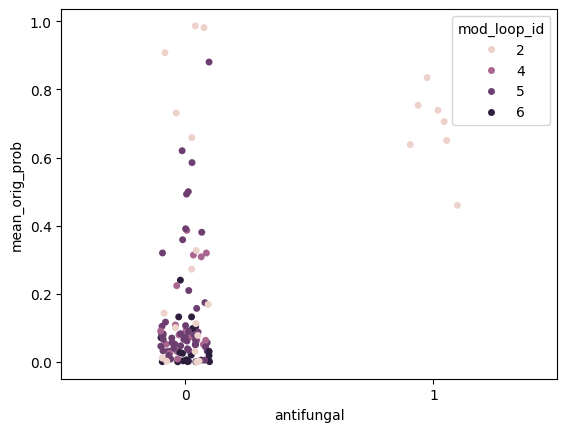

In [162]:
import seaborn as sns

sns.stripplot(x = "antifungal", y = "mean_orig_prob", data=ancestors_table, hue="mod_loop_id")

### Testing Anti-fungal Variants

In [15]:
Antifungal_chitinase_seqs = np.array([list(x[1]) for x in Antifungal_chitinases]) 
Antifungal_chitinase_seqs = Antifungal_chitinase_seqs[:,165:-12]
Antifungal_chitinase_seqs = np.concatenate((Antifungal_chitinase_seqs[:,:96], Antifungal_chitinase_seqs[:,97:]), axis = 1)
Antifungal_chitinase_seqs = [''.join(x) for x in Antifungal_chitinase_seqs.tolist()]

Antifungal_chitinase_names = [x[0] for x in Antifungal_chitinases]
Antifungal_chitinases_clean = [(a,b) for a,b in zip(Antifungal_chitinase_names, Antifungal_chitinase_seqs)]
# del Antifungal_chitinases_clean[9]

In [16]:
ancestors_table

,seq_id,antifungal,mod_loop_id,orig_L1,pred_L1,mean_orig_prob_L1,mean_pred_prob_L1,orig_L2,pred_L2,mean_orig_prob_L2,...,orig_L5,pred_L5,mean_orig_prob_L5,mean_pred_prob_L5,orig_L6,pred_L6,mean_orig_prob_L6,mean_pred_prob_L6,mean_orig_prob,median_pred_prob
0,Anc1_LC_0000001,0,6,,,NaN,NaN,,,NaN,...,,,NaN,NaN,G,V,0.013423,0.042659,0.028381,0.182660
1,Anc1_LC_0000011,0,6,,,NaN,NaN,,,NaN,...,,,NaN,NaN,FG,VG,0.143579,0.146664,0.104599,0.211391
2,Anc1_LC_0000111,0,6,,,NaN,NaN,,,NaN,...,,,NaN,NaN,PFG,AFF,0.239712,0.626325,0.158210,0.596476
3,Anc1_LC_0001111,0,6,,,NaN,NaN,,,NaN,...,,,NaN,NaN,RPFG,AFFT,0.280144,0.632056,0.161517,0.468224
4,Anc1_LC_0011111,0,6,,,NaN,NaN,,,NaN,...,,,NaN,NaN,MRPFG,ALPGA,0.028016,0.144340,0.058098,0.326341
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
110,Anc5_LII_1111111100000,1,2,DGACPAK,DAACRGK,0.579537,0.572087,GGWPTAPD,GGWATAPD,0.823432,...,WTPSAADRAAGR,WTPSGADRAAGR,0.616506,0.666229,YNQRPFG,AFFTACS,0.008830,0.414808,0.544481,0.591679
111,Anc5_LII_1111111110000,1,2,DGACPAK,DAACAGR,0.562000,0.478939,GGWPTAPDG,GGWATAPDG,0.812439,...,WTPSAADRAAGR,WTPKGTDAAAGR,0.627637,0.623172,YNQRPFG,AFFTYDS,0.007774,0.498472,0.583735,0.690707
112,Anc5_LII_1111111111000,1,2,DGACPAK,DNKCQGK,0.581101,0.482429,GGWPTAPDGP,GGWASAPDGP,0.834633,...,WTPSAADRAAGR,WSPNSADAAASR,0.573669,0.591119,YNQRPFG,PITSSQY,0.006740,0.411193,0.557438,0.630207
113,Anc5_LII_1111111111100,1,2,DGACPAK,DAACPNK,0.597018,0.516405,GGWPTAPDGPY,GGWSTAPDGPY,0.829466,...,WTPSAADRAAGR,WSPQSADRTAGR,0.614068,0.626834,YNQRPFG,AFFTYCF,0.004168,0.623488,0.516963,0.634164


In [39]:
# loops_to_include = [2] # Choose a list with elements [1,2,3,4,5,6]
loop_to_ind_map = {1:0,2:1,3:2,4:3,5:4,6:5}

loops_to_include_ind = [loop_to_ind_map[x] for x in loops_to_include]

inverse_loop_map = {0:1,1:2,2:3,3:4,4:5,5:6}

context_path = f"./contexts/loops_{context_loops}.fasta"

context_seqs_MSA = read_msa(context_path)

output_table = []

for loop_number in range(2,3):

    loops_to_include = [loop_number]
    loops_to_include_ind = [loop_to_ind_map[x] for x in loops_to_include]

    for seq in Antifungal_chitinases_clean:
        
        actual_loop_seqs = []
        actual_loop_lens = []
        actual_loop_start_points = []

        offset = 0

        for i in range(len(Loop_start_points)):

            loop_MSA_start = Loop_start_points[i]
            loop_MSA_len = Loop_lengths[i]
            loop_MSA_seq = seq[1][loop_MSA_start: loop_MSA_start + loop_MSA_len]

            loop_seq_actual = loop_MSA_seq.replace("-","")
            loop_len_actual = len(loop_seq_actual)

            actual_loop_seqs.append(loop_seq_actual)
            actual_loop_lens.append(len(loop_seq_actual))
            actual_loop_start_points.append(loop_MSA_start - offset)

            offset += loop_MSA_len - loop_len_actual 

        actual_loop_seqs = np.array(actual_loop_seqs)[loops_to_include_ind].tolist()
        actual_loop_lens = np.array(actual_loop_lens)[loops_to_include_ind].tolist()
        actual_loop_start_points = np.array(actual_loop_start_points)[loops_to_include_ind].tolist()
                
        output = fim([seq[1]], context_seqs_MSA, selected_pos_list = actual_loop_start_points, 
                    original_length_list = actual_loop_lens, gen_length_list = actual_loop_lens, loop_numbers=loops_to_include)
        
        if output == None:
            continue
        
        output_table_record = {"seq_id": seq[0]}

        for ind, k in enumerate(loops_to_include_ind):

            true_loop_number = inverse_loop_map[k]

            output_table_record.update({f"orig_L{true_loop_number}": actual_loop_seqs[ind], f"pred_L{true_loop_number}": output["pred_seqs"][ind],
                                        f"mean_orig_prob_L{true_loop_number}":output["average_orig_prob"][ind], f"mean_pred_prob_L{true_loop_number}":output["average_pred_prob"][ind],
                                        f"median_orig_prob_L{true_loop_number}":output["median_orig_prob"][ind], f"median_pred_prob_L{true_loop_number}":output["median_pred_prob"][ind]})
            
            # output_table_record.update({f"loop_number": true_loop_number, "orig_loop": actual_loop_seqs[ind], "pred_loop": output["pred_seqs"][ind],
            #                             f"mean_orig_prob":output["average_orig_prob"][ind], f"mean_pred_prob":output["average_pred_prob"][ind],
            #                             f"median_orig_prob":output["median_orig_prob"][ind], f"median_pred_prob":output["median_pred_prob"][ind]})

        output_table_record.update({"mean_orig_prob": output["overall_average_orig_prob"], 
                                    "mean_pred_prob": output["overall_average_pred_prob"]})
        
        output_table.append(output_table_record)
    
        
antifungal_table = pd.DataFrame(output_table)
antifungal_table["antifungal"] = 1          




        
        

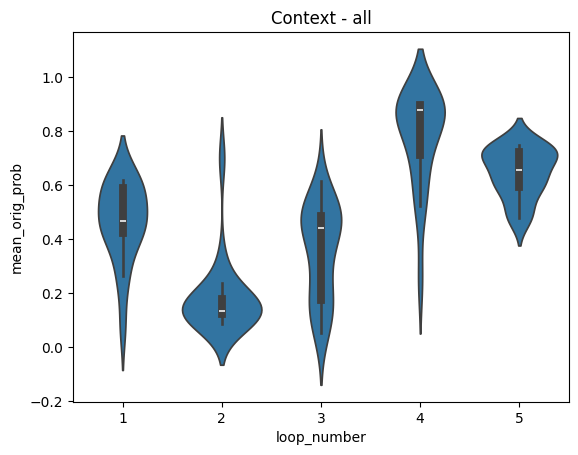

In [332]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots()

sns.violinplot(x = "loop_number", y = "mean_orig_prob", data = antifungal_table, ax = axes)
axes.set_title(f"Context - {context_loops}")

plt.savefig(f"./figures/antifungal_context_{context_loops}_all_loops.png")

In [40]:
common_cols = ["seq_id","mean_orig_prob","mean_pred_prob","antifungal"]

combined_table = pd.concat((ancestors_table[common_cols], antifungal_table[common_cols]), axis = 0).reset_index(drop=True)
combined_table = combined_table.drop_duplicates(subset=["seq_id"])

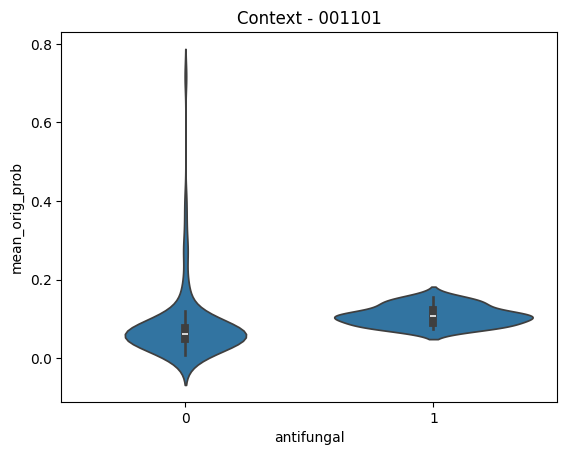

In [41]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots()

sns.violinplot(x = "antifungal", y = "mean_orig_prob", data = combined_table, ax = axes)
axes.set_title(f"Context - {context_loops}")

plt.savefig(f"./figures/antifungal_context_{context_loops}_loop_{loops_to_include[0]}.png")

### Testing other chitinases

In [ ]:
loops_to_include = [2] # Choose a list with elements [1,2,3,4,5,6]
loop_to_ind_map = {1:0,2:1,3:2,4:3,5:4,6:5}

loops_to_include_ind = [loop_to_ind_map[x] for x in loops_to_include]

inverse_loop_map = {0:1,1:2,2:3,3:4,4:5,5:6}

context_path = f"./contexts/loops_{context_loops}.fasta"

context_seqs_MSA = read_msa(context_path)

output_table = []

for ancestor in GH19_MSA:
    
    actual_loop_seqs = []
    actual_loop_lens = []
    actual_loop_start_points = []

    offset = 0

    for i in range(len(Loop_start_points)):

        loop_MSA_start = Loop_start_points[i]
        loop_MSA_len = Loop_lengths[i]
        loop_MSA_seq = ancestor[1][loop_MSA_start: loop_MSA_start + loop_MSA_len]

        loop_seq_actual = loop_MSA_seq.replace("-","")
        loop_len_actual = len(loop_seq_actual)

        actual_loop_seqs.append(loop_seq_actual)
        actual_loop_lens.append(len(loop_seq_actual))
        actual_loop_start_points.append(loop_MSA_start - offset)

        offset += loop_MSA_len - loop_len_actual 

    # if all_loops:

    actual_loop_seqs = np.array(actual_loop_seqs)[loops_to_include].tolist()
    actual_loop_lens = np.array(actual_loop_lens)[loops_to_include].tolist()
    actual_loop_start_points = np.array(actual_loop_start_points)[loops_to_include].tolist()
        
    output = fim([ancestor[1]], context_seqs_MSA, selected_pos_list = actual_loop_start_points, original_length_list= actual_loop_lens, gen_length_list=actual_loop_lens)
    
    if output == None:
        continue
    
    output_table_record = {"seq_id": ancestor[0]}

    for ind, k in enumerate(loops_to_include):

        true_loop_number = inverse_loop_map[k]

        output_table_record.update({f"orig_L{true_loop_number}": actual_loop_seqs[ind], f"pred_L{true_loop_number}": output["pred_seqs"][ind],
                                    f"mean_orig_prob_L{true_loop_number}":output["average_orig_prob"][ind], f"mean_pred_prob_L{true_loop_number}":output["average_pred_prob"][ind]})

    output_table.append(output_table_record)

            




        
        

[0, 0]
[13, 12]
[0, 0]
[0, 0]
[0, 12]
[0, 12]
[13, 12]
[0, 12]
[0, 12]
[0, 12]
[0, 12]
[0, 12]
[0, 12]
[0, 12]
[0, 12]
[0, 12]
[9, 12]
[9, 12]
[11, 12]
[11, 12]
[12, 12]
[12, 12]
[13, 12]
[13, 12]
[13, 12]
[13, 12]
[13, 12]
[12, 12]
[13, 12]
[13, 12]
[13, 12]
[13, 12]
[13, 12]
[13, 12]
[13, 12]
[13, 12]
[13, 12]
[13, 12]
[13, 12]
[13, 12]
[13, 12]
[13, 12]
[13, 12]
[13, 12]
[13, 12]
[13, 12]
[13, 12]
[13, 12]
[13, 12]
[13, 12]
[13, 12]
[13, 12]
[13, 12]
[13, 12]
[13, 12]
[13, 12]
[13, 12]
[13, 12]
[13, 12]
[13, 12]
[13, 12]
[13, 12]
[13, 12]
[13, 12]
[13, 12]
[13, 12]
[13, 12]
[13, 12]
[13, 12]
[13, 12]
[13, 12]
[13, 12]
[13, 12]
[13, 12]
[13, 12]
[13, 12]
[12, 12]
[12, 12]
[12, 12]
[13, 12]
[13, 12]
[13, 12]
[13, 12]
[13, 12]
[13, 12]
[13, 12]
[13, 12]
[13, 12]
[13, 12]
[13, 12]
[13, 12]
[13, 12]
[13, 12]
[13, 12]
[13, 12]
[13, 12]
[13, 12]
[0, 0]
[0, 0]
[0, 0]
[0, 0]
[0, 0]
[0, 0]
[0, 0]
[0, 0]
[0, 0]
[0, 0]
[0, 0]
[0, 0]
[0, 0]
[0, 0]
[0, 0]
[0, 0]
[0, 0]
[0, 0]
[0, 0]
[0, 0]
[0, 0]

In [112]:
output_table= pd.DataFrame(output_table)

In [113]:
output_table

,seq_id,orig_L2,pred_L2,mean_orig_prob_L2,mean_pred_prob_L2,orig_L5,pred_L5,mean_orig_prob_L5,mean_pred_prob_L5
0,L_111111_GH19_PF00182_4DWX_28_259_sp|Q9FRV0|CH...,GGWATAPDGAFAW,GGWATAPDGPYRW,0.602329,0.737525,WSPSGADRAAGR,WTPSADDASAGK,0.440699,0.345088
1,Anc3_001111,,,NaN,NaN,WTPSSADLAANR,WGPTLTAGEITA,0.172052,0.176863
2,Anc4_001111,,,NaN,NaN,WTPSSADLAAGR,WSPTQEEIDGGL,0.297772,0.340175
3,Anc5_111111,GGWPTAPDGPYAW,GGWPTAPTGPYAF,0.685688,0.657461,WTPSAADRAAGR,WGPSADDAAANK,0.310233,0.299647
4,L_001111_GH19_Marchantiophyta_tr|A0A176WJX5|A0...,,,NaN,NaN,WTPTSTDVAASR,WKYTTADGGTKG,0.094607,0.114849
...,...,...,...,...,...,...,...,...,...
89,L_111111_GH19_Sekaginella_tr|D8SUW7|D8SUW7_SEL...,GGWATAPDGPYRW,GGWATAPGGPYLF,0.546253,0.511857,WRPSGADLAAGR,KPSLADVISAKW,0.253542,0.441048
90,L_111111_GH19_PF00182_1DXJ_33_262_tr|O81934|O8...,GGAAGSPDGPYAW,GGWAVSPDQPYPG,0.406141,0.522483,WTPSAADVAANR,ADCQVLAGKIPG,0.138305,0.294418
91,L_111111_GH19_PF00182_3W3E_33_262_tr|Q8H0C9|Q8...,GGAATSPDGPYAW,GGWPAAPAGPYYA,0.504006,0.654792,WTPSAADKAANR,PGGVVTGIVTGG,0.146046,0.312385
92,L_111111_GH19_Magnoliopsida_sp|P36907|CHIX_PEA...,GGWPTAPDGPYAW,GGAGGTSTNQVTN,0.166698,0.348026,WTPSAADSSAGR,GEASTNGYGLIT,0.083997,0.255636


In [65]:
GH19_MSA

[('L_001000_GH19_PF00182_BcChiA_3WH1_35_228_tr|A9ZSX9|A9ZSX9_9BRYO Chitinase A OS=Gemmabryum coronatum OX=216087 GN=bcchiA PE=1 SV=1',
  'VTPAVFEGWFPNRN-------PFYTYDGLVSASNGYPEFGTTGSLDDQKRELAAFLGNINQESG-------------GLQFIQEQNPQSDYCDTSTQYPCAAGKQYYGRGPIQLSWNYNYGEAGADLGLDLLNNPDLVAQDSTVAWRTALWFWMKR-----DCHGAITAS------------PPSFSGTIRIINGGLECNQPANMQMENRVTYYTQFCQTLGVDPGTDLRC-------'),
 ('L_111111_GH19_PF00182_4DWX_28_259_sp|Q9FRV0|CHIC_SECCE Basic endochitinase C OS=Secale cereale OX=4550 GN=rscc PE=1 SV=1',
  'ISHAQFDRMLLHRNDGACQAKGFYTYDAFVAAANAFPGFGATGSTDARKRDVAAFLAQTSHETTGGWATAPDGAFAWGYCFKQERGAAADYCTPSAQWPCAPGKRYYGRGPIQLSHNYNYGPAGRAIGVDLLRNPDLVATDPTVSFKTALWFWMTAQAPKPSSHAVITGKWSPSGADRAAGRAPGFGVITNIINGGLECGHGQDSRVADRIGFYKRYCDILGVGYGDNLDCYNQRPFA'),
 ('Anc1_001000',
  'VTQAMFNQLFPNRN-------SFYTYDAFIAAANSFPAFGTTGSTDVRKREIAAFFAHVSHETG-------------GLVYIEEIDQSNDYCDSSTQYPCAPGKQYYGRGPIQLSWNYNYGAAGEALGLDLLNNPDLVAQDAVIAFKTALWFWMTQ-----SCHDAMVSN------------VPGFGATIRIINGGLECNKGNPAQVENRVNYYKDFCQQLGVSPGSNL